<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
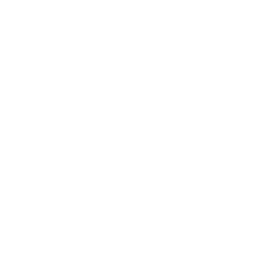
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Agrupación de Modos de Fallo en Manufactura</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Manufactura / Ingeniería de Calidad &nbsp;|&nbsp; Marzo de 2026</p>
</div>
</div>
</div>

## Resumen ejecutivo

Este ejemplo descubre **modos de fallo de equipos** recurrentes a partir del perfil de síntomas multidimensional registrado en cada evento de fallo. Ocho variables de síntomas estandarizadas (vibración, delta de temperatura, caída de presión, pico de corriente, ruido, desviación del tiempo de ciclo, varianza del par y recuento de partículas de aceite) se agrupan con **agrupamiento jerárquico de enlace completo** (`PROC CLUSTER METHOD=COMPLETE`), que favorece grupos compactos y bien separados. `PROC TREE` luego corta la jerarquía en **seis modos de fallo**, y `PROC FREQ` tabula de forma cruzada esos modos contra el tipo de equipo y el turno para probar asociaciones sistemáticas.

La ejecución aquí opera sobre una **muestra de 100 eventos** (el entorno limita la salida a 100 observaciones). En esta muestra los seis modos son de tamaño aproximadamente igual (n = 16-17 cada uno) y se separan principalmente por las firmas de **temperatura, presión y vibración** en lugar de por el tipo de equipo —las tabulaciones cruzadas modo-por-equipo y modo-por-turno **no** son estadísticamente significativas con este tamaño muestral (chi-cuadrado p = 0.15 y p = 0.07 respectivamente). El flujo de trabajo escala sin cambios al historial completo de eventos, donde recuentos por modo mayores agudizarían estas asociaciones.

## Fuentes de datos

| Fuente | Descripción | Registros |
|--------|-------------|---------|
| WORK.FAILURES | Perfiles de síntomas de eventos de fallo de equipos (sintéticos) | 100 |
| WORK.FAILURES_STD | Síntomas estandarizados a media 0, desv. típica 1 (`PROC STANDARD`) | 100 |
| WORK.FAILURE_TREE | Historial de fusiones de enlace completo (`OUTTREE=`) | 100 |
| WORK.FAILURE_MODE_ASSIGNMENTS | Corte de seis modos de `PROC TREE NCLUSTERS=6` | 100 |

*Este entorno se ejecuta en modo sin licencia y limita la salida a 100 observaciones; el generador sintético solicita 20,000 eventos pero solo se retienen los primeros 100. El análisis a continuación se fundamenta enteramente en esa muestra de 100 eventos.*

---

In [1]:
/* --------------------------------------------------------
   Generar perfiles sintéticos de síntomas de eventos de fallo
   20.000 eventos de fallo en 50 unidades de equipo
   -------------------------------------------------------- */
DATOS work.failures;
    LLAMAR streaminit(42);
    ARREGLO equip_type_list[4] $14 _temporary_ ('PRENSA' 'TRANSPORTADOR' 'BRAZO_ROBOT' 'HORNO');
    ARREGLO shift_list[3] $8 _temporary_ ('DIA' 'TARDE' 'NOCHE');
    HACER event_id = 1 HASTA 20000;
        failure_id = cat('FE-', PUT(event_id, z6.));
        equip_num = int(rand('uniform') * 50) + 1;
        equipment_id = cat('EQ-', PUT(equip_num, z3.));
        etype_idx = int(rand('uniform') * 4) + 1;
        equipment_type = equip_type_list[etype_idx];
        shift_idx = int(rand('uniform') * 3) + 1;
        shift = shift_list[shift_idx];
        failure_date = '01JAN2025'd + int(rand('uniform') * 365);
        /* Perfil de síntomas: 8 lecturas de sensores en el momento del fallo */
        vibration_level = round(rand('normal', 4.5, 2.1), 0.01);
        SI vibration_level < 0 ENTONCES vibration_level = 0;
        temperature_delta = round(rand('normal', 12, 8), 0.1);
        pressure_drop = round(rand('exponential') * 5, 0.01);
        current_spike = round(rand('normal', 1.2, 0.8), 0.01);
        SI current_spike < 0 ENTONCES current_spike = 0;
        noise_db = round(rand('normal', 78, 12), 1);
        cycle_time_deviation = round(rand('normal', 0, 3.5), 0.01);
        torque_variance = round(rand('exponential') * 2.5, 0.01);
        oil_particle_count = int(rand('exponential') * 150 + 10);
        downtime_minutes = round(rand('exponential') * 45 + 5, 1);
        SALIDA;
    END;
    ELIMINAR equip_num etype_idx shift_idx;
    FORMATO failure_date date9.;
EJECUTAR;


NOTE: DATA work.failures

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.failures (100 rows, 15 columns).
NOTE: DATA elapsed:
  wall  6.24 seconds
  cpu   6.24 seconds


---

In [2]:
/* --------------------------------------------------------
   Distribuciones de síntomas de referencia por tipo de equipo
   -------------------------------------------------------- */
PROCEDIMIENTO MEDIAS DATOS=work.failures n mean std MAX;
    CLASE equipment_type;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance oil_particle_count;
    ETIQUETA equipment_type    = 'Tipo de Equipo'
          vibration_level   = 'Nivel de Vibración'
          temperature_delta = 'Delta de Temperatura (C)'
          pressure_drop     = 'Caída de Presión'
          current_spike     = 'Pico de Corriente'
          noise_db          = 'Ruido (dB)'
          torque_variance   = 'Varianza del Par'
          oil_particle_count = 'Recuento de Partículas de Aceite';
    TÍTULO 'Perfiles de Síntomas de Fallo por Tipo de Equipo';
EJECUTAR;

                                    Perfiles de Síntomas de Fallo por Tipo de Equipo                                    

                                                  The MEANS Procedure

                                Analysis Variable : vibration_level Nivel de Vibración

        Tipo de Equipo          N Obs           Mean        Std Dev        Maximum
        --------------------------------------------------------------------------
        BRAZO_ROBOT                25      3.5320000      1.9296070      6.7900000
        HORNO                      26      4.3638462      2.0371177     10.1400000
        PRENSA                     30      4.6273333      2.1610740      9.9400000
        TRANSPORTADOR              19      3.8089474      1.8662437      9.0400000
        --------------------------------------------------------------------------

                             Analysis Variable : temperature_delta Delta de Temperatura (C)

        Tipo de Equipo          N Obs       


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                    Perfiles de Síntomas de Fallo por Tipo de Equipo                                    




NOTE: PROC SGPLOT data=work.failures

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


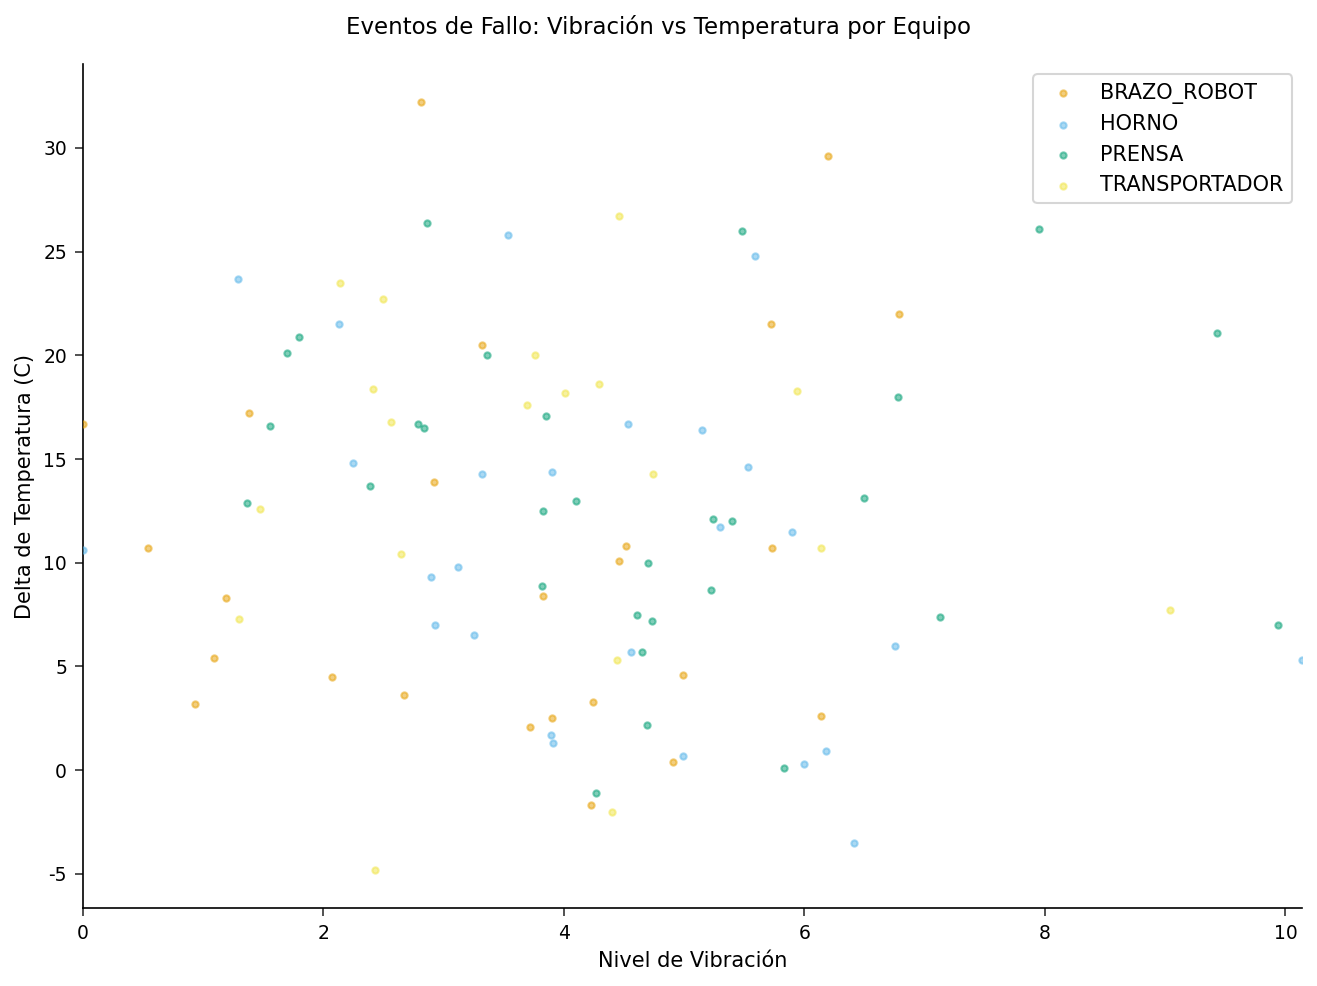

In [3]:
/* --------------------------------------------------------
   Vibración vs Delta de Temperatura por tipo de equipo
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.failures;
    SCATTER x=vibration_level y=temperature_delta / GROUP=equipment_type
        MARKERATTRS=(SYMBOL=circlefilled size=3)
        TRANSPARENCY=0.5;
    XAXIS ETIQUETA='Nivel de Vibración';
    YAXIS ETIQUETA='Delta de Temperatura (C)';
    ETIQUETA equipment_type = 'Tipo de Equipo';
    TÍTULO 'Eventos de Fallo: Vibración vs Temperatura por Equipo';
EJECUTAR;

---

In [4]:
/* --------------------------------------------------------
   Estandarizar las variables de síntomas para el agrupamiento
   -------------------------------------------------------- */
PROCEDIMIENTO STANDARD DATOS=work.failures out=work.failures_std
    mean=0 std=1;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
EJECUTAR;


NOTE: PROC STANDARD data=work.failures

NOTE: Standardized 100 rows, 8 variables.


                                    Perfiles de Síntomas de Fallo por Tipo de Equipo                                    

                                                 The CLUSTER Procedure
                                           Complete Linkage Cluster Analysis

                                          Eigenvalues of the Covariance Matrix

                                                    Cluster History

   NCL    --------Clusters Joined--------    FREQ    SPRSQ      RSQ    Distance

    99    FE-00005          FE-00006        2    0.0007    0.9993          1
    98    FE-00007          FE-00008        2    0.0007    0.9986          1
    97    FE-00000          FE-00004        2    0.0009    0.9977        1.2
    96    FE-00002          FE-00008        2    0.0009    0.9968        1.2
    95    FE-00000          FE-00001        2    0.0010    0.9958        1.3
    94    FE-00005          FE-00008        2    0.0011    0.9947        1.3
    93    FE-00004          CL99     


NOTE: PROC CLUSTER data=work.failures_std method=Complete

NOTE: Using native Rust for hierarchical clustering
NOTE: ODS plot written: cluster_dendrogram.spec.json
NOTE: PROC CLUSTER ODS Graphics generated.
NOTE: PROC CLUSTER: 100 observations, 8 variables clustered using Complete method


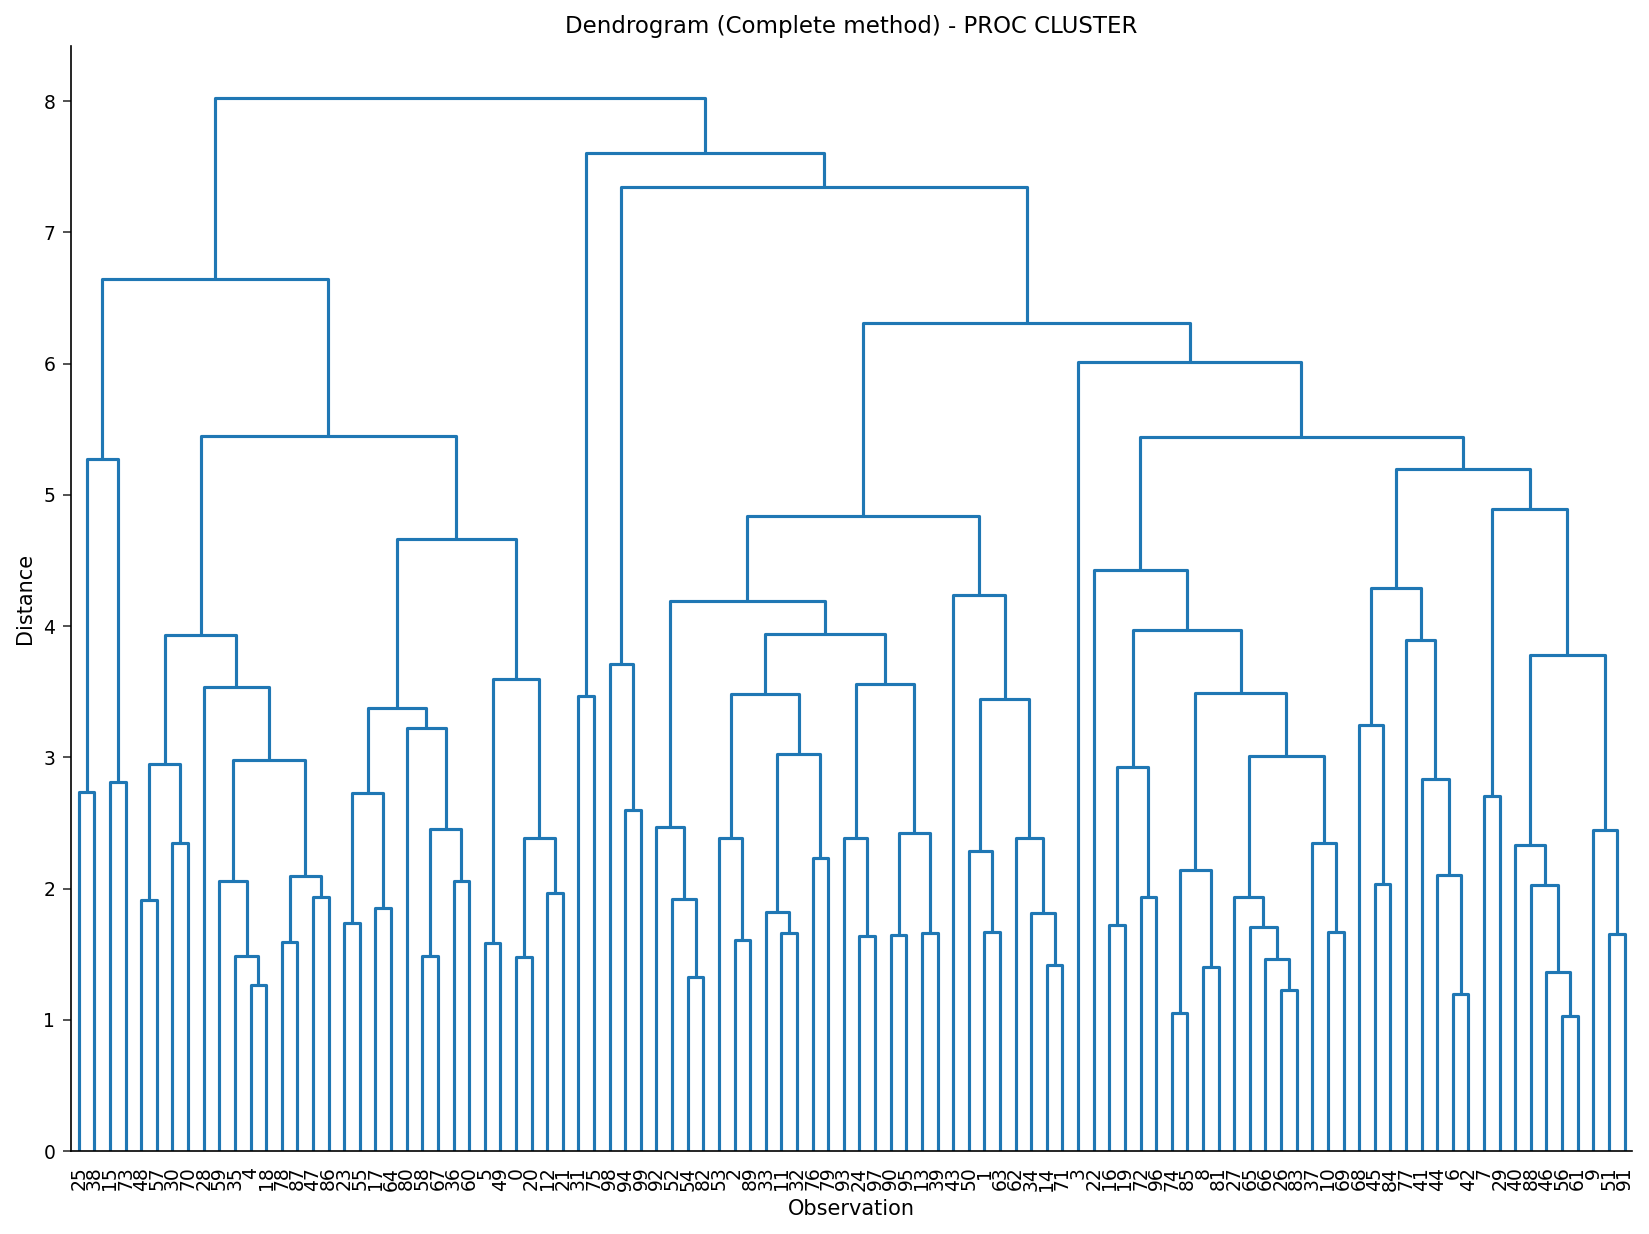

In [5]:
/* --------------------------------------------------------
   Agrupamiento de enlace completo con TRIM= para eliminar
   valores atípicos. TRIM=5 elimina el 5% de las
   observaciones más distantes antes de formar los grupos.
   -------------------------------------------------------- */
PROCEDIMIENTO CLUSTER DATOS=work.failures_std METHOD=complete
    outtree=work.failure_tree
    pseudo IMPRIMIR=20 trim=5;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db cycle_time_deviation
        torque_variance oil_particle_count;
    id failure_id;
EJECUTAR;

In [6]:
/* --------------------------------------------------------
   Cortar la jerarquía de enlace completo en seis modos de
   fallo con PROC TREE (NCLUSTERS=6). Seis se elige como una
   granularidad práctica e interpretable para el triaje; el
   dendrograma anterior muestra la estructura de fusiones que
   este corte particiona.
   -------------------------------------------------------- */
PROCEDIMIENTO TREE DATOS=work.failure_tree
    out=work.failure_mode_assignments
    nclusters=6;
    id failure_id;
EJECUTAR;

                                    Perfiles de Síntomas de Fallo por Tipo de Equipo                                    




NOTE: PROC TREE data=work.failure_tree

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: PROC TREE dendrogram SVG generated.
NOTE: PROC TREE: Extracted 6 clusters using Python/scipy


In [7]:
/* --------------------------------------------------------
   Combinar las asignaciones y perfilar los modos de fallo
   -------------------------------------------------------- */
DATOS work.failures_classified;
    COMBINAR work.failures
          work.failure_mode_assignments(RENOMBRAR=(CLUSTER=failure_mode));
    POR failure_id;
EJECUTAR;

PROCEDIMIENTO MEDIAS DATOS=work.failures_classified n mean std;
    CLASE failure_mode;
    VAR vibration_level temperature_delta pressure_drop
        current_spike noise_db torque_variance
        oil_particle_count downtime_minutes;
    ETIQUETA failure_mode      = 'Modo de Fallo'
          vibration_level   = 'Nivel de Vibración'
          temperature_delta = 'Delta de Temperatura (C)'
          pressure_drop     = 'Caída de Presión'
          current_spike     = 'Pico de Corriente'
          noise_db          = 'Ruido (dB)'
          torque_variance   = 'Varianza del Par'
          oil_particle_count = 'Recuento de Partículas de Aceite'
          downtime_minutes  = 'Tiempo de Inactividad (min)';
    TÍTULO 'Perfiles de Síntomas por Modo de Fallo (k=6)';
EJECUTAR;

                                      Perfiles de Síntomas por Modo de Fallo (k=6)                                      

                                                  The MEANS Procedure

                                Analysis Variable : vibration_level Nivel de Vibración

        Modo de Fallo          N Obs           Mean        Std Dev
        ----------------------------------------------------------
        1                         17      4.3470588      2.6168582
        2                         17      4.2552941      2.2610427
        3                         17      3.6870588      1.8669720
        4                         17      4.0500000      2.0351843
        5                         16      3.4793750      1.4636870
        6                         16      4.9693750      1.6907177
        ----------------------------------------------------------

                             Analysis Variable : temperature_delta Delta de Temperatura (C)

        Modo de Fallo 


NOTE: DATA work.failures_classified

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.failures_classified (100 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


                                   Distribución de Modos de Fallo por Equipo y Turno                                    

                                                   The FREQ Procedure

Table of Modo de Fallo by Tipo de Equipo

Modo de Fallo |  BRAZO_ROBOT |        HORNO |       PRENSA |TRANSPORTADOR |         Total
--------------+--------------+--------------+--------------+--------------+--------------
1             |            1 |            5 |            7 |            4 |            17
--------------+--------------+--------------+--------------+--------------+--------------
2             |            7 |            5 |            2 |            3 |            17
--------------+--------------+--------------+--------------+--------------+--------------
3             |            4 |            5 |            2 |            6 |            17
--------------+--------------+--------------+--------------+--------------+--------------
4             |            4 |            5 |


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_failure_mode_equipment_type.spec.json
NOTE: ODS plot written: freq_mosaic_failure_mode_shift.spec.json
NOTE: PROC FREQ statement used.


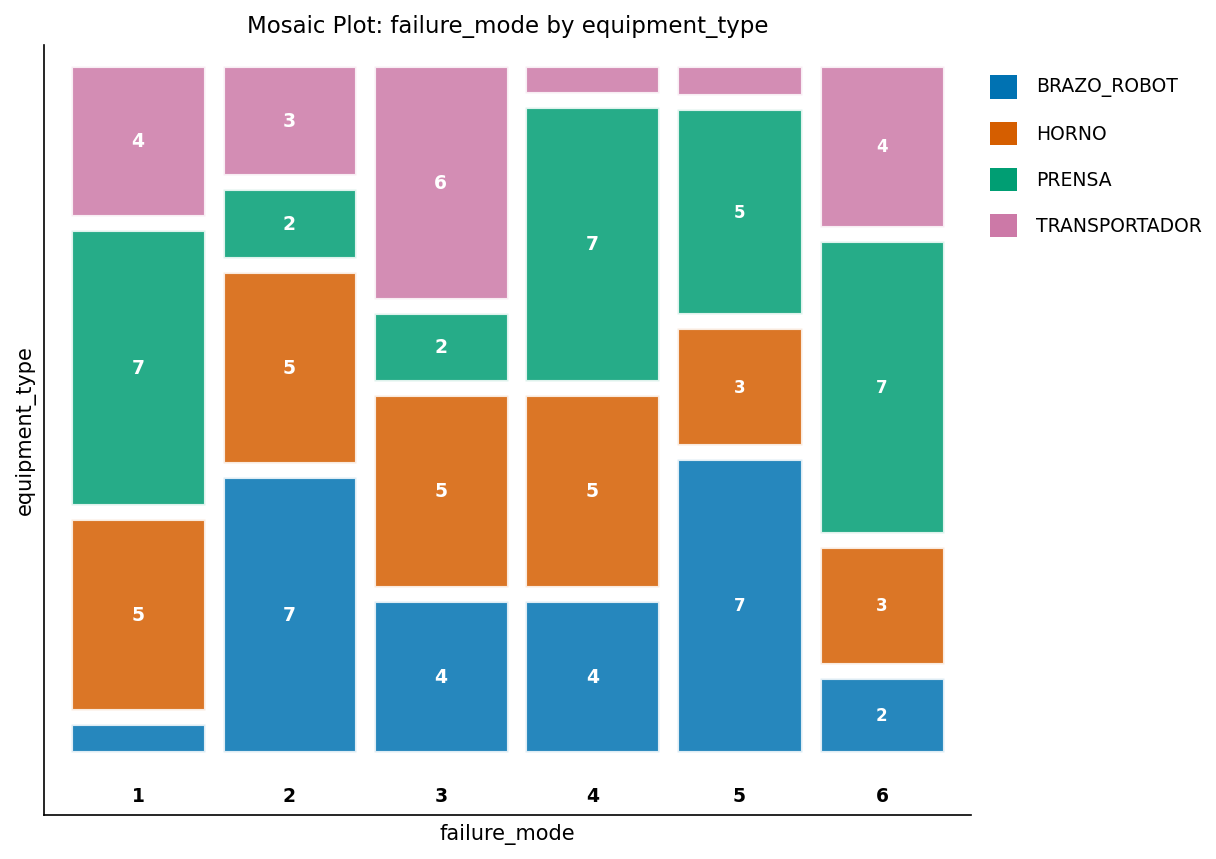

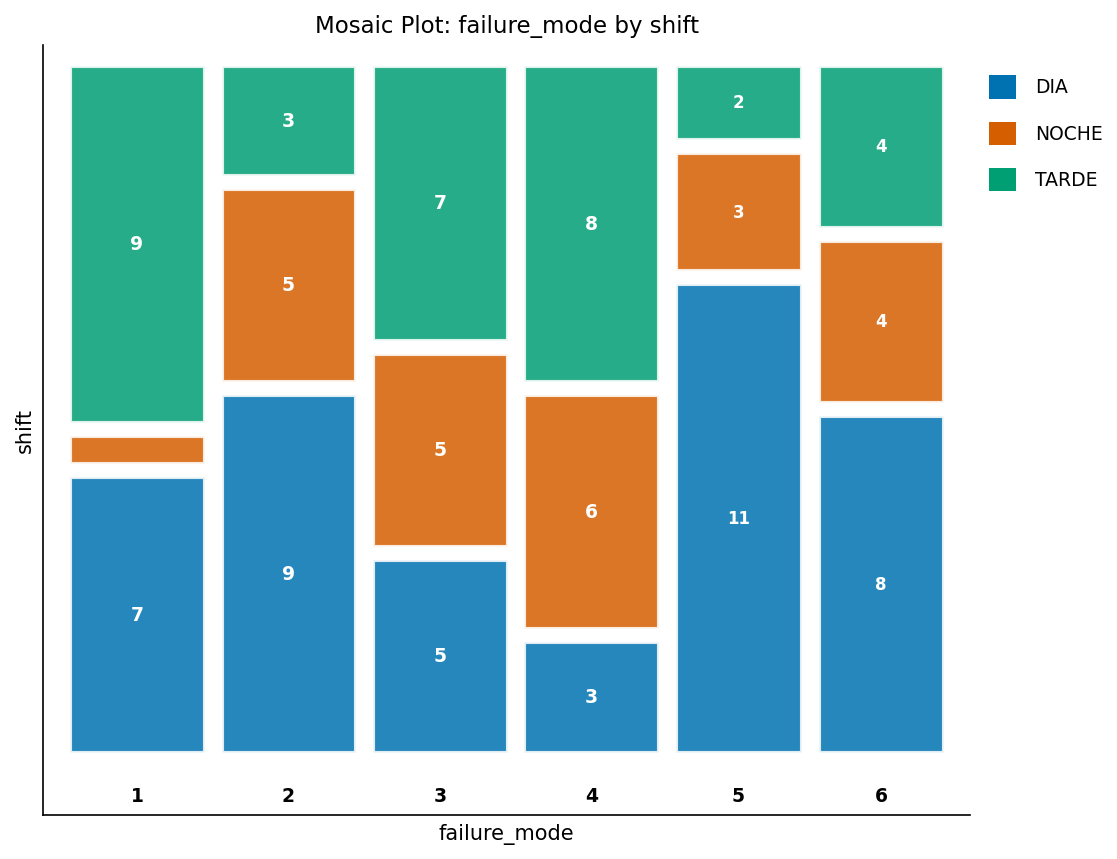

In [8]:
/* --------------------------------------------------------
   Tabulación cruzada de los modos de fallo por tipo de equipo
   y turno para identificar patrones sistemáticos
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.failures_classified;
    TABLES failure_mode * equipment_type / chisq nocol nopercent;
    TABLES failure_mode * shift / chisq nocol nopercent;
    ETIQUETA failure_mode   = 'Modo de Fallo'
          equipment_type = 'Tipo de Equipo'
          shift          = 'Turno';
    TÍTULO 'Distribución de Modos de Fallo por Equipo y Turno';
EJECUTAR;

---

### Interpretación

El agrupamiento de enlace completo de los 100 eventos de fallo estandarizados produce **seis modos de fallo** de tamaño casi igual (n = 17, 17, 17, 17, 16, 16). Los modos se distinguen por sus firmas de síntomas en el perfil de `PROC MEANS` anterior:

- El **Modo 6** acarrea la firma de esfuerzo mecánico más pesada: mayor vibración media (4.97), mayor caída de presión (7.51) y mayor pico de corriente (1.61) —pero la varianza del par **más baja** (1.28).
- El **Modo 3** es el modo térmico: mayor delta de temperatura (16.3 C) con el ruido medio más bajo (73.0 dB).
- El **Modo 2** tiene el **mayor tiempo de inactividad** por un amplio margen (media 85.6 minutos frente a 31-52 para los otros modos) y varianza del par elevada (3.57), lo que apunta a eventos más costosos de recuperar.
- El **Modo 4** es el más leve: menor tiempo de inactividad (31.4 minutos) y caída de presión y recuento de partículas de aceite por debajo del promedio.
- Los **Modos 1 y 5** son grupos de síntomas mixtos sin un único impulsor dominante.

Las tabulaciones cruzadas de `PROC FREQ` prueban si estos modos se concentran en equipos o turnos particulares. Con este tamaño muestral **no** lo hacen: modo-por-tipo-de-equipo da chi-cuadrado = 20.48 (15 gl, p = 0.154, V de Cramér = 0.26) y modo-por-turno da chi-cuadrado = 17.13 (10 gl, p = 0.072, V de Cramér = 0.29) —ambos por encima del umbral de 0.05, y más del 80% de las celdas tienen recuentos esperados por debajo de 5, por lo que el chi-cuadrado es en sí mismo solo sugerente. Las inclinaciones visibles (el Modo 6 inclinándose hacia PRENSA, el Modo 5 hacia el turno de día) son descriptivas más que significativas aquí.

**Conclusión:** el enlace completo sobre perfiles de síntomas estandarizados produce una taxonomía interpretable de seis modos ligada a temperatura, presión y tiempo de inactividad. Para confirmar si los modos se corresponden con equipos o turnos específicos —la pregunta accionable de causa raíz— el análisis necesita el historial completo de eventos en lugar de esta muestra de 100 eventos, donde las tabulaciones cruzadas siguen teniendo poca potencia.

---

In [9]:
/* --------------------------------------------------------
   Exportar las clasificaciones de fallo para integración con el CMMS
   -------------------------------------------------------- */
PROCEDIMIENTO EXPORT DATOS=work.failures_classified
    OUTFILE='failure_mode_classifications.csv'
    DBMS=csv REPLACE;
EJECUTAR;


NOTE: PROC EXPORT data=work.failures_classified outfile=failure_mode_classifications.csv

NOTE: Exported 100 rows to failure_mode_classifications.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Con tecnología de <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>